In [17]:
import numpy as np
from scipy.optimize import root_scalar
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt

#### Pulling in the Sim result

In [20]:
# Pulling in the sim result
result = pyreadr.read_r('full_simulation_results8.rds')

# Extract the DataFrame
sim_result = list(result.values())[0]

sim_result["weighted_eer"] = sim_result["weighting"] * sim_result["eer"]
sim_result["weighted_treatment_eer"] = sim_result["weighting"] * sim_result["treatment_eer"]

#### FAOSTAT Demand and supply curves

In [22]:
norm = pd.read_csv("Food data/FoodBalanceSheets_E_All_Data_(Normalized)/FoodBalanceSheets_E_All_Data_(Normalized).csv")
raw = pd.read_csv("Food data/FoodBalanceSheets_E_All_Data/FoodBalanceSheets_E_All_Data.csv")
mapping = pd.read_csv("Food data/FBS_Group_Mapping.csv")
iso_mapping = pd.read_csv("Food data/faostat_country_mapping.csv")
price_index = pd.read_csv("Food data/ConsumerPriceIndices_E_All_Data_(Normalized)/ConsumerPriceIndices_E_All_Data_(Normalized).csv")
elasticity_supply_raw = pd.read_csv("Food data/elasticity_supply.csv")
elasticity_demand = pd.read_csv("Food data/elasticity_demand.csv")
carbon_intensity_raw = pd.read_csv("Food data/carbon_intensity.csv")

In [23]:
countries_in_scope = sim_result["ISO"].unique()
# Cleaning and mapping Faostat
food_norm = pd.merge(norm,iso_mapping,on="Area",how="left")
food_norm = food_norm.loc[(food_norm["Year"]==2022)&(food_norm["Element"]=="Food")&(food_norm["ISO"].isin(sim_result["ISO"].unique()))]
food_norm = pd.merge(food_norm,mapping.set_index("fbs_group")[["first_level_aggregation","final_food_group"]],left_on="Item",right_index=True,how="left")
food_grouped = food_norm.groupby(["Area","ISO","final_food_group"]).sum()[["Value"]].reset_index()
food_grouped = food_grouped[food_grouped["ISO"].isin(countries_in_scope)].rename(columns={"Area":"Country","Value":"initial_eql_quantity"}).reset_index(drop=True)

# Cleaning and Mapping price
price_clean = pd.merge(price_index,iso_mapping,on="Area",how="left")
price_clean = price_clean.loc[(price_clean["Months"]=="December")& \
                              (price_clean["Year"]==2022)& \
                              (price_clean["Item"]=="Consumer Prices, Food Indices (2015 = 100)")]
price_clean = price_clean[price_clean["ISO"].isin(countries_in_scope)][["Area","ISO","Value"]].rename(columns={"Area":"Country","Value":"price"}).reset_index(drop=True)

# Normalizing Supply
elasticity_supply = elasticity_supply_raw.melt(
    id_vars=["ISO", "Country", "Region"],
    var_name="final_food_group",
    value_name="elasticity_supply")

# Normalizing Carbon intensity
carbon_intensity = carbon_intensity_raw.melt(
    id_vars=["ISO", "Country", "Region"],
    var_name="final_food_group",
    value_name="carbon_intensity_t")
carbon_intensity["carbon_intensity_t"] = carbon_intensity["carbon_intensity_t"] * 1000

In [71]:
missing_faostat = [country for country in countries_in_scope if country not in food_grouped["ISO"].unique()]
print("List of ISO not in FAOSTAT:", missing_faostat)

missing_price = [country for country in countries_in_scope if country not in price_clean["ISO"].unique()]
print("List of ISO not in price data:", missing_price)

List of ISO not in FAOSTAT: ['ASM', 'AND', 'BMU', 'BRN', 'GRL', 'PRI', 'SGP']
List of ISO not in price data: ['ASM', 'AND', 'BMU', 'BRN', 'GRL', 'GUY', 'NRU', 'PRI', 'SGP', 'TWN']


#### Making the Model

In [15]:
# Making the merged dataframe
merged = pd.merge(food_grouped,price_clean[["ISO","price"]],on="ISO",how="outer")
merged = pd.merge(merged,elasticity_demand.set_index("food_groups"),left_on="final_food_group",right_index=True,how="left")
merged = pd.merge(merged,elasticity_supply[["ISO","final_food_group","elasticity_supply"]],on=["ISO","final_food_group"],how="left")

# Calculating constant Cs (Qs/(Ps^Es)) and Cd (Qd/(Pd^Ed))
merged["Cs"] = merged["initial_eql_quantity"]/(merged["price"]**merged["elasticity_supply"])
merged["Cd"] = merged["initial_eql_quantity"]/(merged["price"]**merged["elasticity_demand"])

# Calculating the country level percentage decrease in demand
sim_result_perc = sim_result.groupby(["ISO","scenario"]).sum()
sim_result_perc = sim_result_perc[["weighted_eer","weighted_treatment_eer"]].copy()
sim_result_perc["diff"] = sim_result_perc["weighted_treatment_eer"] - sim_result_perc["weighted_eer"]
sim_result_perc["expected_demand_reduction_percent"] = (sim_result_perc["weighted_treatment_eer"]/sim_result_perc["weighted_eer"]) - 1

# Merging the percentage decrease onto the merged dataframe
merged = pd.merge(merged,sim_result_perc[["expected_demand_reduction_percent"]].reset_index(),on="ISO",how="left")
merged

,Country,ISO,final_food_group,initial_eql_quantity,price,elasticity_demand,elasticity_supply,Cs,Cd,scenario,expected_demand_reduction_percent
0,United Arab Emirates,ARE,Cereals,4044.0,117.912830,-0.43,0.29,1014.047827,3.144723e+04,max_uptake,-0.021985
1,United Arab Emirates,ARE,Cereals,4044.0,117.912830,-0.43,0.29,1014.047827,3.144723e+04,mod_uptake,-0.011933
2,United Arab Emirates,ARE,Dairy,2470.0,117.912830,-0.60,0.29,619.361556,4.321491e+04,max_uptake,-0.021985
3,United Arab Emirates,ARE,Dairy,2470.0,117.912830,-0.60,0.29,619.361556,4.321491e+04,mod_uptake,-0.011933
4,United Arab Emirates,ARE,Eggs,230.0,117.912830,-0.36,0.29,57.673343,1.280825e+03,max_uptake,-0.021985
...,...,...,...,...,...,...,...,...,...,...,...
1003,United States of America,USA,Meat,83456.0,123.572386,-0.60,0.63,4013.719912,1.501794e+06,mod_uptake,-0.014969
1004,United States of America,USA,Other,69223.0,123.572386,-0.77,0.63,3329.200219,2.825075e+06,max_uptake,-0.029537
1005,United States of America,USA,Other,69223.0,123.572386,-0.77,0.63,3329.200219,2.825075e+06,mod_uptake,-0.014969
1006,United States of America,USA,"Sweets, confectionery, and sweetened beverages",45402.0,123.572386,-0.56,0.63,2183.556742,6.738310e+05,max_uptake,-0.029537


In [128]:
from scipy.optimize import root_scalar

# Function to compute the difference between supply and (shocked) demand
def equilibrium_gap(P, Cs, Cd, Es, Ed, demand_shock_pct):
    Qs = Cs * (P ** Es)
    Qd = Cd * (P ** Ed) * (1 + demand_shock_pct)
    return Qs - Qd  # root of this gives equilibrium

# Example row input: country-food group specific values
def compute_equilibrium(row):
    try:
        result = root_scalar(
            equilibrium_gap,
            args=(row['Cs'], row['Cd'], row['elasticity_supply'], row['elasticity_demand'], row['expected_demand_reduction_percent']),
            method='brentq',
            bracket=[1e-3, 1e3],  # Avoid divide-by-zero or negative powers
        )
        if result.converged:
            P_new = result.root
            Q_eql_new = row['Cs'] * (P_new ** row['elasticity_supply'])  # Or use Cd * P^Ed
            return pd.Series({'P_eq_new': P_new, 'Q_eql_new': Q_eql_new})
        else:
            return pd.Series({'P_eq_new': np.nan, 'Q_eql_new': np.nan})
    except:
        return pd.Series({'P_eq_new': np.nan, 'Q_eql_new': np.nan})

# Computing the new equilibrium price and Quantity
result_df = merged.copy()
result_df["expected_demand_reduction"] = result_df["initial_eql_quantity"] * (result_df["expected_demand_reduction_percent"])
result_df[['P_eq_new', 'Q_eql_new']] = result_df.apply(compute_equilibrium, axis=1)

# Computing the magnitude of rebound effect
result_df["actual_reduction"] =  result_df["Q_eql_new"] - result_df["initial_eql_quantity"]
result_df["rebound_effect"] = result_df["actual_reduction"] - result_df["expected_demand_reduction"]
result_df["rebound_effect_percent"] = -1*result_df["rebound_effect"]/result_df["expected_demand_reduction"]

# Calculating the Carbon savings
result_df = pd.merge(result_df,carbon_intensity[["ISO","final_food_group","carbon_intensity_t"]],how="left",on=["ISO","final_food_group"])
result_df["carbon_savings_t"] = result_df["actual_reduction"] * result_df["carbon_intensity_t"]
result_df

,Country,ISO,final_food_group,initial_eql_quantity,price,elasticity_demand,elasticity_supply,Cs,Cd,scenario,expected_demand_reduction_percent,expected_demand_reduction,P_eq_new,Q_eql_new,actual_reduction,rebound_effect,rebound_effect_percent,carbon_intensity_t,carbon_savings_t
0,United Arab Emirates,ARE,Cereals,4044.0,117.912830,-0.43,0.29,1014.047827,3.144723e+04,max_uptake,-0.021985,-88.907731,114.327840,4007.952057,-36.047943,52.859788,0.594547,2000.0,-7.209589e+04
1,United Arab Emirates,ARE,Cereals,4044.0,117.912830,-0.43,0.29,1014.047827,3.144723e+04,mod_uptake,-0.011933,-48.255415,115.963200,4024.494092,-19.505908,28.749508,0.595778,2000.0,-3.901182e+04
2,United Arab Emirates,ARE,Dairy,2470.0,117.912830,-0.60,0.29,619.361556,4.321491e+04,max_uptake,-0.021985,-54.303189,115.004088,2452.172942,-17.827058,36.476131,0.671713,4200.0,-7.487364e+04
3,United Arab Emirates,ARE,Dairy,2470.0,117.912830,-0.60,0.29,619.361556,4.321491e+04,mod_uptake,-0.011933,-29.473510,116.333094,2460.357384,-9.642616,19.830895,0.672838,4200.0,-4.049899e+04
4,United Arab Emirates,ARE,Eggs,230.0,117.912830,-0.36,0.29,57.673343,1.280825e+03,max_uptake,-0.021985,-5.056572,113.948325,227.730097,-2.269903,2.786669,0.551099,4200.0,-9.533592e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,United States of America,USA,Meat,83456.0,123.572386,-0.60,0.63,4013.719912,1.501794e+06,mod_uptake,-0.014969,-1249.256600,122.066398,82813.783226,-642.216774,607.039826,0.485921,1600.0,-1.027547e+06
1004,United States of America,USA,Other,69223.0,123.572386,-0.77,0.63,3329.200219,2.825075e+06,max_uptake,-0.029537,-2044.650272,120.954117,68295.317478,-927.682522,1116.967750,0.546288,1000.0,-9.276825e+05
1005,United States of America,USA,Other,69223.0,123.572386,-0.77,0.63,3329.200219,2.825075e+06,mod_uptake,-0.014969,-1036.202186,122.248285,68754.774547,-468.225453,567.976733,0.548133,1000.0,-4.682255e+05
1006,United States of America,USA,"Sweets, confectionery, and sweetened beverages",45402.0,123.572386,-0.56,0.63,2183.556742,6.738310e+05,max_uptake,-0.029537,-1341.045774,120.497863,44687.027616,-714.972384,626.073390,0.466855,1000.0,-7.149724e+05


#### Plots

,0
Country,United Arab Emirates
ISO,ARE
final_food_group,Cereals
initial_eql_quantity,4044.0
price,117.91283
elasticity_demand,-0.43
elasticity_supply,0.29
Cs,1014.047827
Cd,31447.230501
scenario,max_uptake


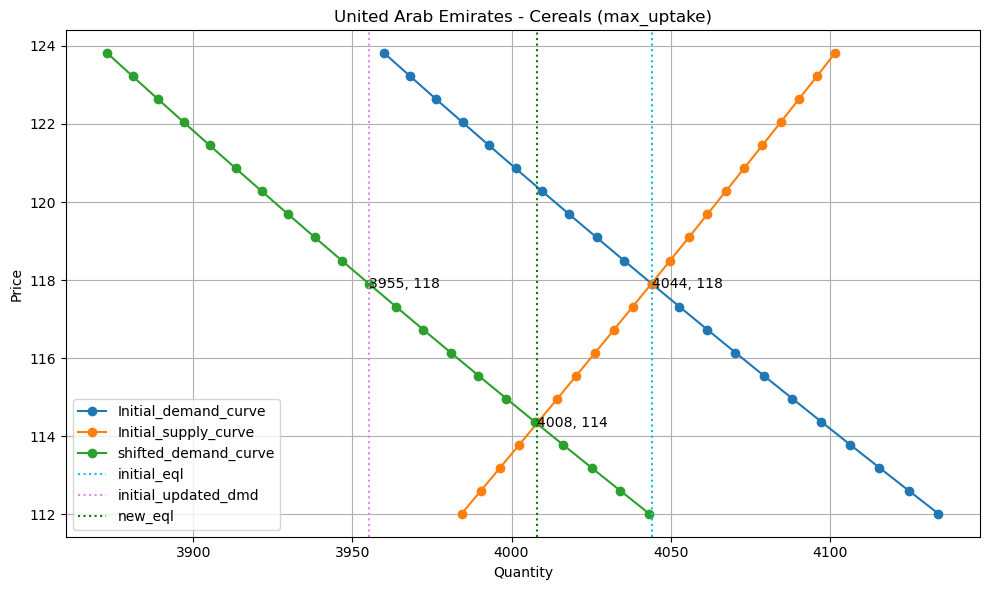

In [110]:
# Checking the calcuction
def plot_equilibrium_curves(row_index, df):
    display(df.iloc[[row_index]].T)
    row = df.iloc[row_index]
    
    # Extract parameters
    Cd = row['Cd']
    Cs = row['Cs']
    Ed = row['elasticity_demand']
    Es = row['elasticity_supply']
    P0 = row['price']
    shock_pct = row['expected_demand_reduction_percent']
    Q_init = row['initial_eql_quantity']
    Q_new = row['Q_eql_new']
    
    # Generate price range +/- 5% around original price
    prices = np.arange(P0 * 0.95, P0 * 1.05, P0 * 0.005)
    
    # Calculate quantities
    Qd = Cd * prices**Ed
    Qs = Cs * prices**Es
    Qd_shifted = Qd * (1 + shock_pct)
    
    # Calculate corresponding quantities at equilibrium
    Q_shock_target = Q_init * (1 + shock_pct)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(Qd, prices, label='Initial_demand_curve', marker='o')
    plt.plot(Qs, prices, label='Initial_supply_curve', marker='o')
    plt.plot(Qd_shifted, prices, label='shifted_demand_curve', marker='o')
    
    # Vertical lines
    plt.axvline(Q_init, color='deepskyblue', linestyle='dotted', label='initial_eql')
    plt.axvline(Q_shock_target, color='violet', linestyle='dotted', label='initial_updated_dmd')
    plt.axvline(Q_new, color='green', linestyle='dotted', label='new_eql')
    
    # Annotations
    plt.text(Q_init, P0, f'{Q_init:.0f}, {P0:.0f}', ha='left', va='center')
    plt.text(Q_shock_target, P0, f'{Q_shock_target:.0f}, {P0:.0f}', ha='left', va='center')
    plt.text(Q_new, row['P_eq_new'], f'{Q_new:.0f}, {row["P_eq_new"]:.0f}', ha='left', va='center')
    
    plt.xlabel('Quantity')
    plt.ylabel('Price')
    plt.title(f"{row['Country']} - {row['final_food_group']} ({row['scenario']})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

row_check = result_df.iloc[0]

plot_equilibrium_curves(0,result_df)

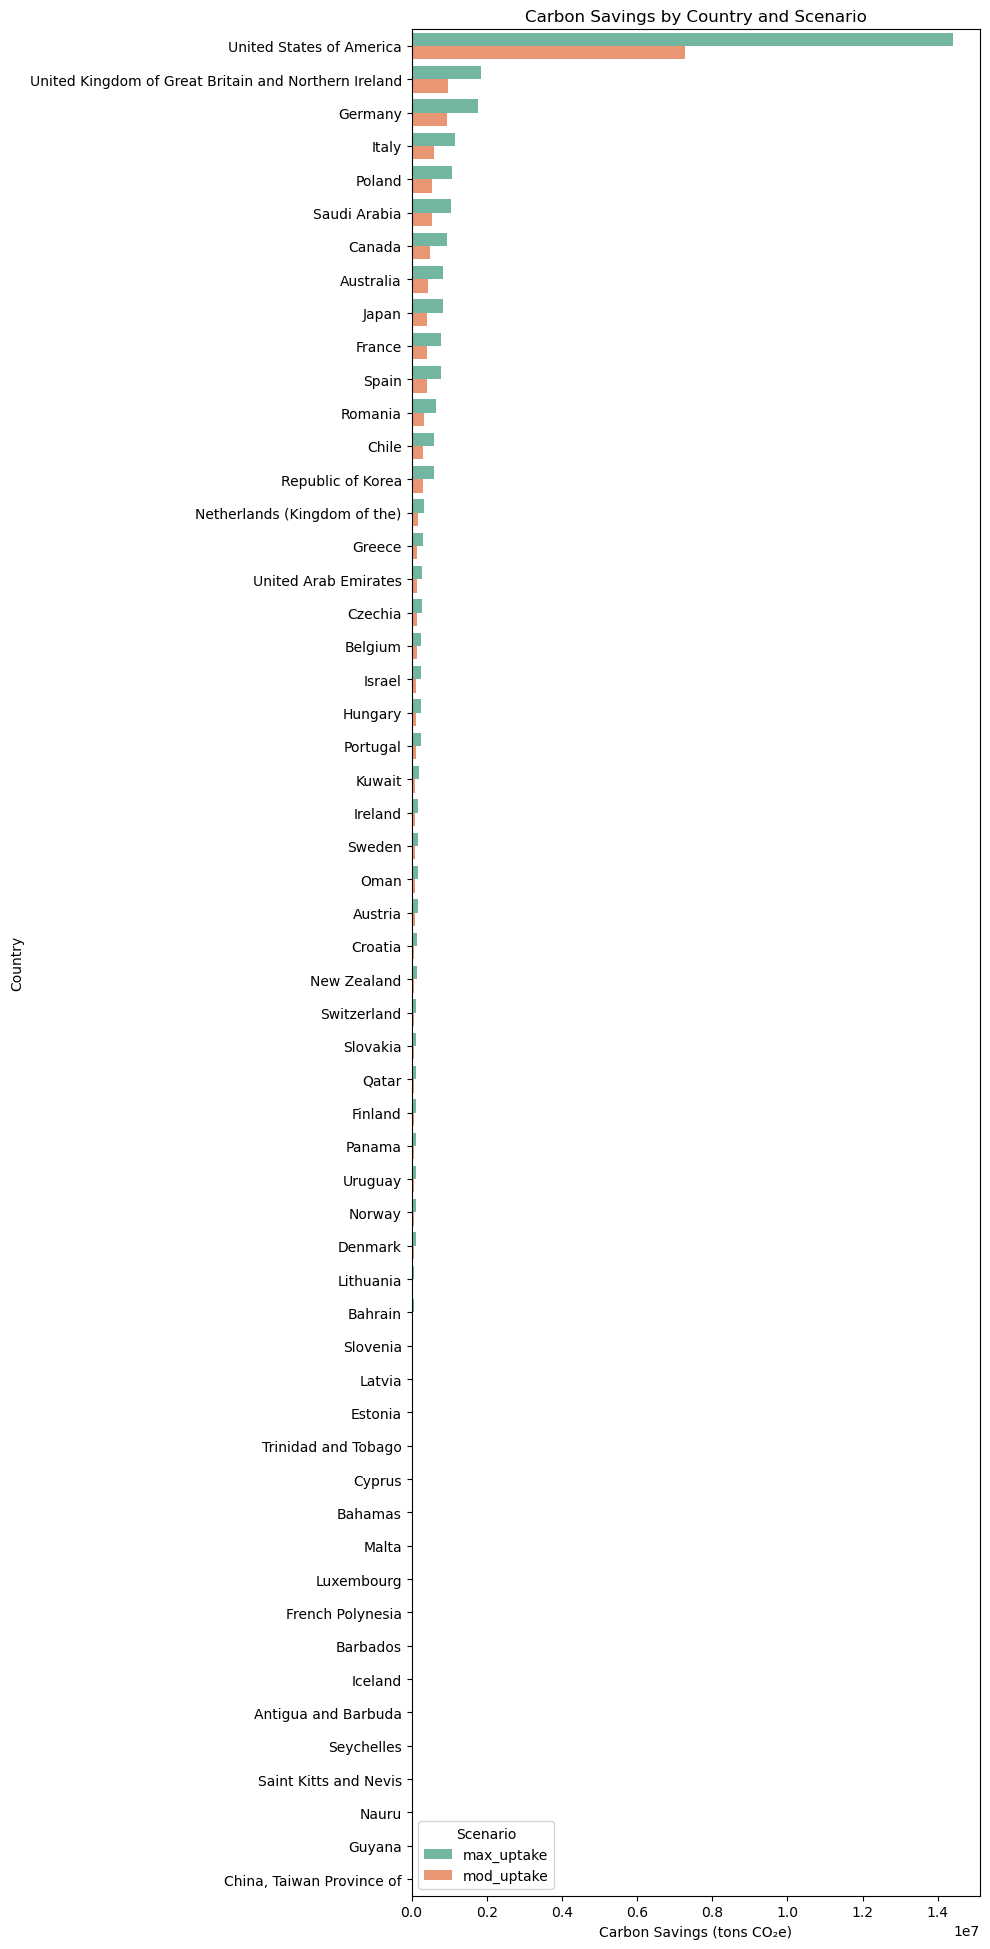

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Country and Scenario
grouped = result_df.groupby(['Country', 'scenario'])['carbon_savings_t'].sum().reset_index()

# Sort countries by total savings (optional, for consistent ordering)
country_order = grouped.groupby('Country')['carbon_savings_t'].sum().sort_values(ascending=False).index

# Vertical grouped bar chart
plt.figure(figsize=(10, len(country_order) * 0.35))  # Adjust height based on number of countries
sns.barplot(
    data=grouped,
    y='Country',
    x='carbon_savings_t',
    hue='scenario',
    order=country_order,
    palette='Set2'
)

plt.xlabel('Carbon Savings (tons CO₂e)')
plt.ylabel('Country')
plt.title('Carbon Savings by Country and Scenario')
plt.legend(title='Scenario')
plt.tight_layout()
plt.show()

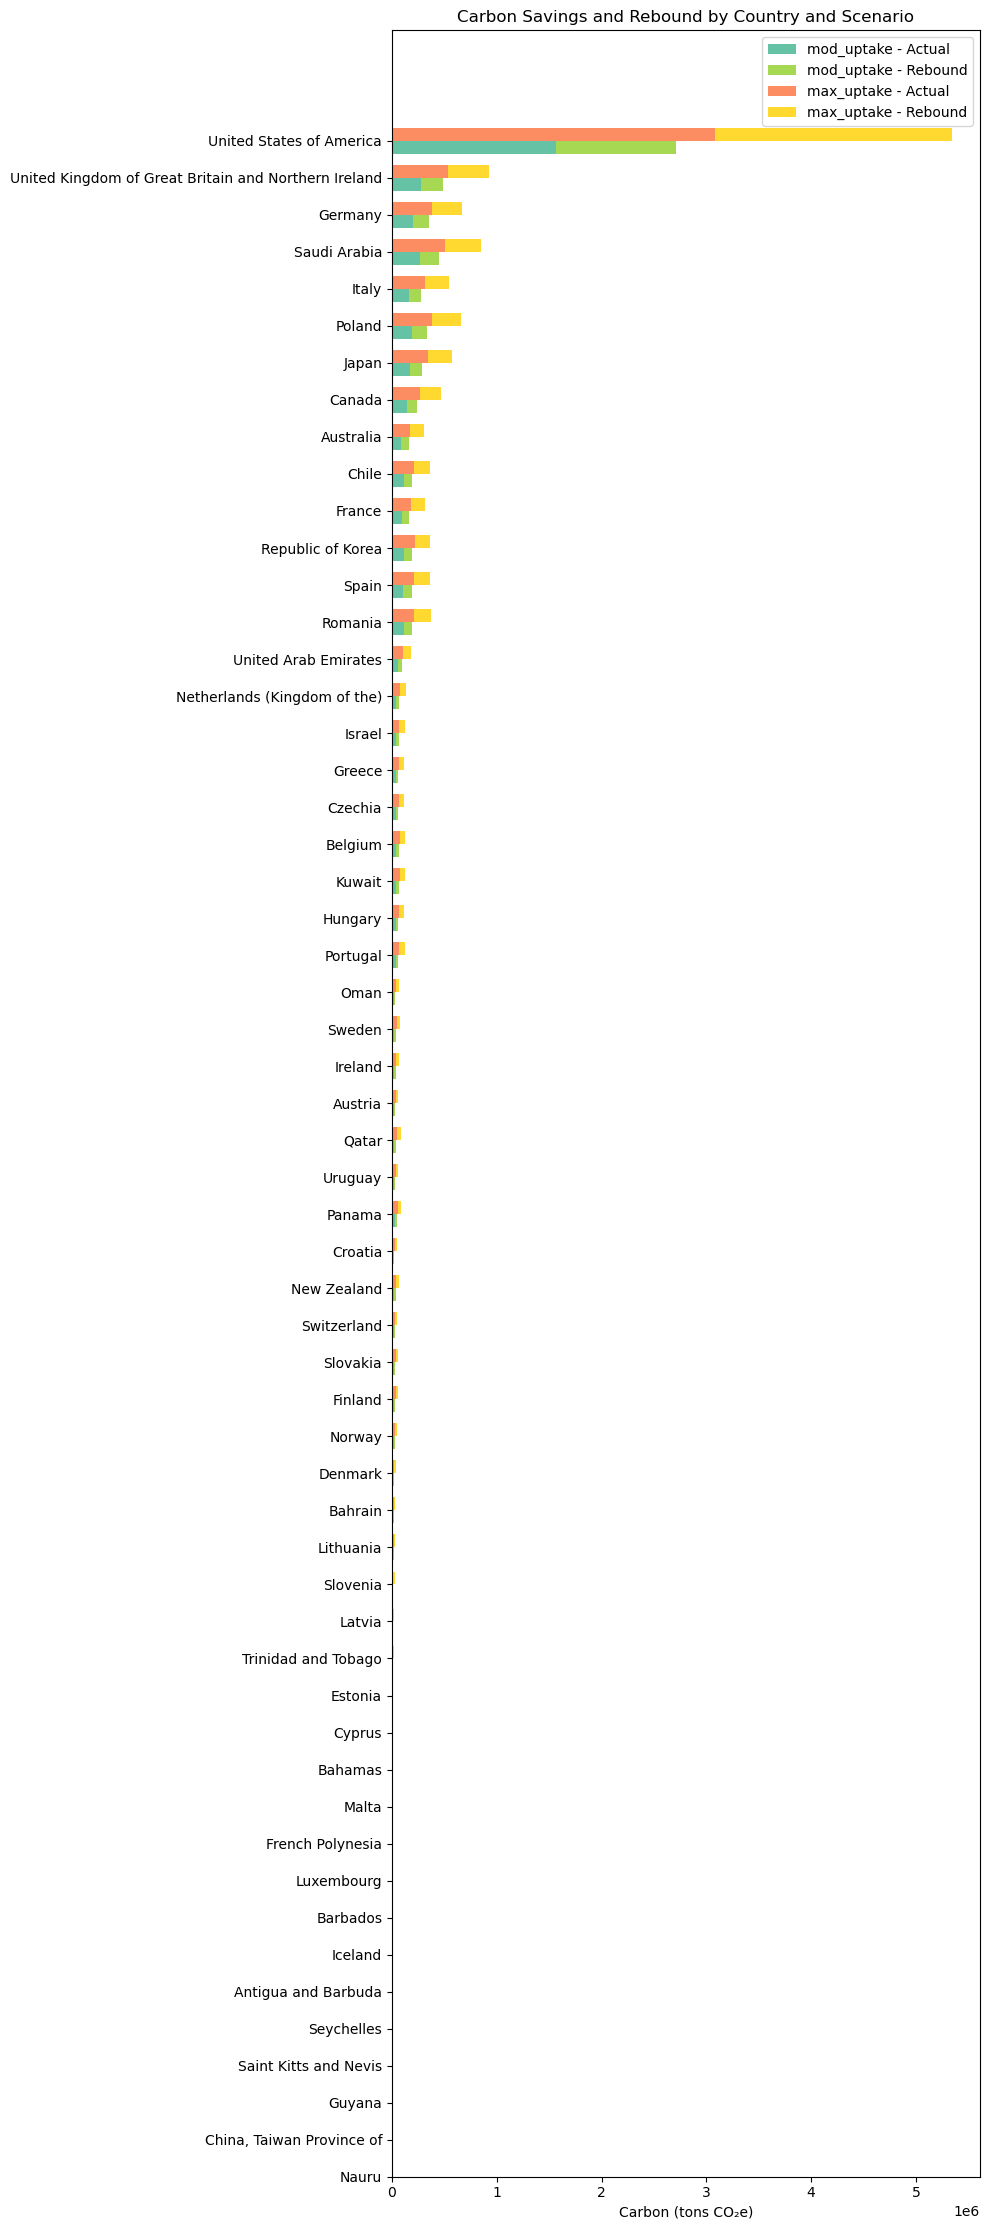

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
df = result_df.copy()
df['total_savings'] = -1 * df['expected_demand_reduction'] * df['carbon_intensity_t']
df['rebound_emissions'] = df['rebound_effect'] * df['carbon_intensity_t']
df['actual_savings'] = df['total_savings'] - df['rebound_emissions']

# Sum total by country for sorting
df['combined'] = df['actual_savings'] + df['rebound_emissions']
country_order = (
    df.groupby('Country')['combined']
    .sum()
    .sort_values(ascending=True)
    .index.tolist()
)

# Set plotting positions
scenarios = ['mod_uptake', 'max_uptake']
bar_height = 0.35
y = np.arange(len(country_order))

# Collect values
actual = {s: [] for s in scenarios}
rebound = {s: [] for s in scenarios}

for country in country_order:
    for s in scenarios:
        row = df[(df['Country'] == country) & (df['scenario'] == s)]
        if not row.empty:
            actual_val = row['actual_savings'].values[0]
            rebound_val = row['rebound_emissions'].values[0]
        else:
            actual_val = 0
            rebound_val = 0
        actual[s].append(actual_val)
        rebound[s].append(rebound_val)

# Colors per scenario
scenario_colors = {
    'mod_uptake': ('#66c2a5', '#a6d854'),  # (actual, rebound)
    'max_uptake': ('#fc8d62', '#ffd92f')
}

# Plot
plt.figure(figsize=(10, len(country_order) * 0.4))
for i, s in enumerate(scenarios):
    pos = y + (i - 0.5) * bar_height
    plt.barh(pos, actual[s], bar_height, label=f'{s} - Actual', color=scenario_colors[s][0])
    plt.barh(pos, rebound[s], bar_height, left=actual[s], label=f'{s} - Rebound', color=scenario_colors[s][1])

plt.yticks(y, country_order)
plt.xlabel('Carbon (tons CO₂e)')
plt.title('Carbon Savings and Rebound by Country and Scenario')
plt.legend()
plt.tight_layout()
plt.show()

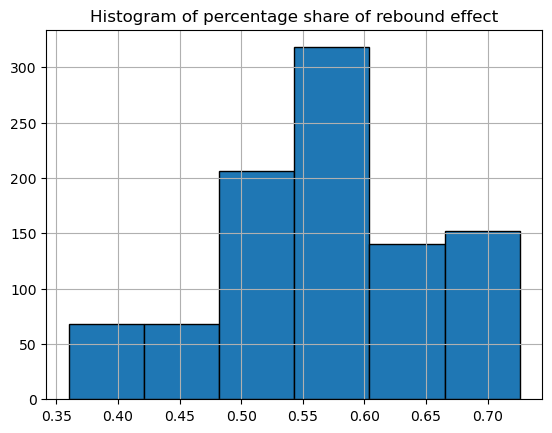

Text(0.5, 1.0, 'Histogram of Expected demand reduction country level')

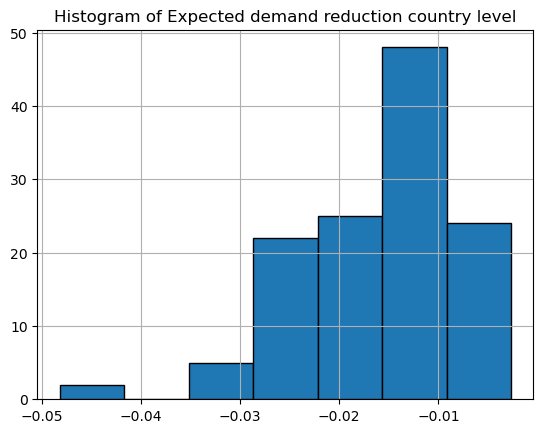

In [122]:
import matplotlib.pyplot as plt

result_df['rebound_effect_percent'].hist(bins=6, edgecolor='black')
plt.title('Histogram of percentage share of rebound effect')
plt.show()
sim_result_perc['expected_demand_reduction_percent'].hist(bins=7, edgecolor='black')
plt.title('Histogram of Expected demand reduction country level')